# PS-S5E12: Model Blending

This notebook tackles the [**Playground Series – Season 6, Episode 1: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s6e1), a competition focused on predicting the exam score for a student, based on features describing the student, the exam, and the facility.

## Ensemble Strategy: Hill Climbing with Rank Normalization

Model blending is the process of combining predictions from multiple diverse models to create a single, more robust prediction. For this competition, we are using a **Hill Climbing** algorithm on **Rank-Normalized (CDF)** predictions.

### Why Rank Normalization?
Different gradient boosting libraries (XGBoost, LightGBM, CatBoost) output probabilities with different distributions. For example, XGBoost might output values clustered around 0.1 and 0.9, while CatBoost might be more conservative, staying between 0.3 and 0.7. Averaging these raw values can let one over-confident model dominate the ensemble.

*   **Solution:** We convert all predictions to their **CDF (Cumulative Distribution Function)** values, effectively turning them into **Ranks** (0.0 to 1.0). This puts all models on the same scale while preserving the relative ordering of samples, which is exactly what the **AUC metric** cares about.
    

### Why Hill Climbing?
Instead of guessing weights (e.g., `0.33*XGB + 0.33*LGB + 0.33*CB`), Hill Climbing finds the optimal weights automatically.

*   **Algorithm:** It starts with the single best model. In each iteration, it tries adding every available model to the current ensemble. It permanently adds the one that maximizes the Cross-Validation AUC.
    
*   **Result:** If the algorithm adds XGBoost 3 times and CatBoost 7 times, the final weights are naturally `0.3` and `0.7`. This method is robust, essentially impossible to overfit if done on OOF data, and highly effective for maximizing AUC.

## Install Needed Packages

In [1]:
import os
import glob
import warnings

# --- Third-party
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from scipy.stats import rankdata
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

from ps_s06e01_experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'exam_score'

Random seed set to: 10301
Warnings suppressed.


In [3]:
# Load Ground Truth
training_df = helper.read_training_dataset()
y_true = training_df[TARGET].values

TRAINING DATASET

   id  age  gender   course  study_hours  class_attendance internet_access  \
0   0   21  female     b.sc        7.910            98.800              no   
1   1   18   other  diploma        4.950            94.800             yes   
2   2   20  female     b.sc        4.680            92.600             yes   
3   3   19    male     b.sc        2.000            49.500             yes   
4   4   23    male      bca        7.650            86.900             yes   

   sleep_hours sleep_quality   study_method facility_rating exam_difficulty  \
0        4.900       average  online videos             low            easy   
1        4.700          poor     self-study          medium        moderate   
2        5.800          poor       coaching            high        moderate   
3        8.300       average    group study            high        moderate   
4        9.600          good     self-study            high            easy   

   exam_score  
0      78.300  
1     

In [4]:
submission_df = helper.read_sample_submission_dataset()

## Loading OOF and Test Predictions
We load the Out-of-Fold (OOF) predictions and Test predictions generated by our individual model notebooks.
*   **OOF Predictions:** used to train the ensemble weights. Because these predictions were made on data the models _didn't_ see during training, they provide an unbiased estimate of performance.
*   **Test Predictions:** The final target we want to predict. We will apply the learned weights to these.

In [5]:
oof_files = []
test_files = []

if helper.running_in_kaggle():
    pred_dir = '/kaggle/input/ps-s06e01-*/predictions'
else:
    pred_dir = 'predictions'

oof_files = sorted(glob.glob(f'{pred_dir}/*_oof_preds.csv'))
test_files = sorted(glob.glob(f'{pred_dir}/*_test_preds.csv'))

print(f"Found {len(oof_files)} OOF files and {len(test_files)} Test files.")

Found 3 OOF files and 3 Test files.


In [6]:
# Helper to load and merge predictions
def load_preds(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        model_name = os.path.basename(file).replace('_oof_preds.csv', '').replace('_test_preds.csv', '')
        # Read file
        df = pd.read_csv(file)
        
        # If files contain 'id' and 'pred', index by id. 
        # Assuming the column naming convention is standard (e.g. 'pred_xgb', 'diagnosed_diabetes', or similar)
        # We will dynamically find the prediction column (not 'id' or 'target')
        pred_col = [c for c in df.columns if c not in ['id', TARGET]][0]
        
        df = df.rename(columns={pred_col: model_name})
        df = df.set_index(index_col)[model_name]
        df_list.append(df)
        
    return pd.concat(df_list, axis=1)

In [12]:
# Create DataFrames
oof_df = load_preds(oof_files)
test_df = load_preds(test_files)

# Make sure y_true is indexed by id and aligned to oof_df
train_y = training_df.set_index('id')[TARGET]

# Keep only rows where all models have predictions
oof_df = oof_df.sort_index()
oof_df = oof_df.dropna(axis=0)

# Align y_true to the remaining ids
y_true_aligned = train_y.loc[oof_df.index].values

print(f"OOF Shape: {oof_df.shape}")
print(f"Test Shape: {test_df.shape}")

Series([], dtype: int64)
Rows with any NaN: 0
OOF Shape: (630000, 3)
Test Shape: (270000, 3)


## Rank Normalization (CDF Transform)
Here we transform the raw probability scores into uniform \[0, 1\] distributions based on rank.
*   **Code logic:** `rankdata(x) / len(x)`
*   **Effect:** This ensures that a model predicting 0.99 isn't weighted 10x more than a model predicting 0.90 just because of calibration differences. It forces the ensemble to rely on the _ordering_ quality of the models.

In [8]:
# Check individual scores after transformation
print("\nIndividual Model RMSE (Ranked):")
best_single_model = None
best_single_score = 101

for model in oof_df.columns:
    score = np.sqrt(mean_squared_error(y_true_aligned, oof_df[model]))
    print(f"{model}: {score:.6f}")
    if score < best_single_score:
        best_single_score = score
        best_single_model = model

print(f"\nBest model/score: {best_single_model}/{best_single_score:.6f}")


Individual Model RMSE (Ranked):
cb: 8.744109
lgb: 8.740232
xgb: 8.750152

Best model/score: lgb/8.740232


## Hill Climbing Algorithm

We run the optimization loop for a fixed number of iterations (e.g., 200).
1.  **Initialize:** Start with the single best performing model.
2.  **Iterate:** In each round, tentatively add every model (XGB, LGB, CB) to the current ensemble sum.
3.  **Evaluate:** Calculate the new RMSE for each candidate addition.
4.  **Select:** Permanently add the model that resulted in the highest RMSE decrease.
5.  **Repeat:** Continue allowing models to be added (accumulating weights) until the score plateaus or iterations run out.

The final count of how many times a model was added becomes its weight in the final blend.

In [17]:
# Hill Climbing Algorithm (Caruana et al.)
# Iteratively adds the model that maximizes the ensemble AUC
def hill_climbing(oof_pred_df, y, iterations=100, verbose=False):
    # sanity checks
    if oof_pred_df.isna().any().any():
        bad = oof_pred_df.isna().sum().sort_values(ascending=False)
        raise ValueError(f"NaNs in oof_pred_df:\n{bad[bad>0]}")
    if np.isnan(y).any():
        raise ValueError("NaNs in y")

    # pick best single model here (don’t rely on outer globals)
    best_single_model = None
    best_single_score = np.inf
    for col in oof_pred_df.columns:
        s = np.sqrt(mean_squared_error(y, oof_pred_df[col].values))
        if np.isfinite(s) and s < best_single_score:
            best_single_score = s
            best_single_model = col
    if best_single_model is None:
        raise RuntimeError("No finite single-model RMSE found (check preds/y).")

    current_sum = oof_pred_df[best_single_model].values.copy()
    k = 1

    model_counts = {c: 0 for c in oof_pred_df.columns}
    model_counts[best_single_model] = 1
    history = [best_single_score]
    
    print(f"\nStarting Hill Climbing for {iterations} iterations...")
    
    for i in range(iterations):
        best_step_score = np.inf
        best_step_col = None
        
        # Try adding each model to the current ensemble
        for col in oof_pred_df.columns:
            temp_avg = (current_sum + oof_pred_df[col].values) / (k + 1)
            score = np.sqrt(mean_squared_error(y, temp_avg))
            
            if np.isfinite(score) and score < best_step_score:
                best_step_score = score
                best_step_col = col

        if best_step_col is None:
            # show diagnostics instead of crashing
            raise RuntimeError(
                f"No finite candidate at iter {i+1}. "
                f"Any NaNs in current_sum? {np.isnan(current_sum).any()}; "
                f"Any NaNs in oof_pred_df? {oof_pred_df.isna().any().any()}"
            )

        # Update the ensemble with the winner of this round
        current_sum += oof_pred_df[best_step_col].values
        k += 1
        model_counts[best_step_col] += 1
        history.append(best_step_score)

        if verbose and (i % 10 == 0):
            print(f"Iter {i+1}: +{best_step_col} -> RMSE {best_step_score:.6f}")

    # Calculate final weights
    total = sum(model_counts.values())
    weights = {m: c / total for m, c in model_counts.items() if c > 0}
    return weights, history


Starting Hill Climbing for 200 iterations...
Iter 1: +xgb -> RMSE 8.726643
Iter 11: +xgb -> RMSE 8.724604
Iter 21: +cb -> RMSE 8.724557
Iter 31: +lgb -> RMSE 8.724534
Iter 41: +cb -> RMSE 8.724529
Iter 51: +lgb -> RMSE 8.724528
Iter 61: +xgb -> RMSE 8.724529
Iter 71: +xgb -> RMSE 8.724529
Iter 81: +lgb -> RMSE 8.724529
Iter 91: +cb -> RMSE 8.724529
Iter 101: +lgb -> RMSE 8.724527
Iter 111: +lgb -> RMSE 8.724528
Iter 121: +xgb -> RMSE 8.724527
Iter 131: +xgb -> RMSE 8.724528
Iter 141: +xgb -> RMSE 8.724528
Iter 151: +cb -> RMSE 8.724527
Iter 161: +lgb -> RMSE 8.724527
Iter 171: +cb -> RMSE 8.724527
Iter 181: +xgb -> RMSE 8.724527
Iter 191: +xgb -> RMSE 8.724527

Optimal Blending Weights:
xgb: 0.3831
lgb: 0.3632
cb: 0.2537


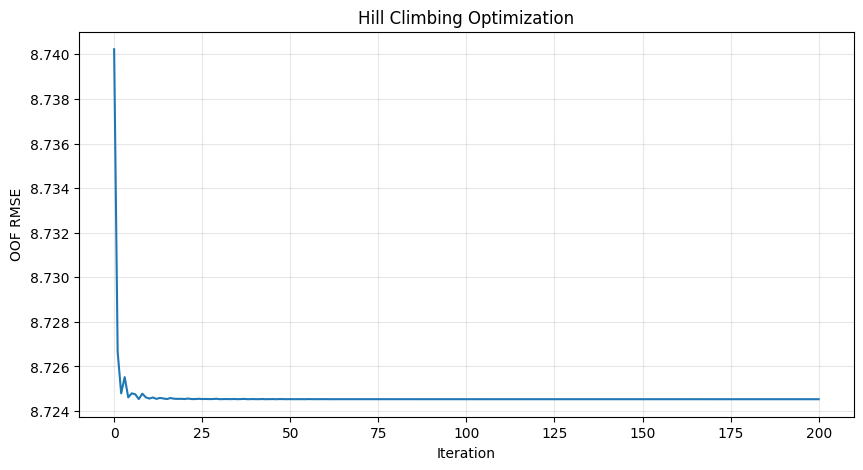

In [18]:
# Run Optimization
weights, history = hill_climbing(oof_df, y_true_aligned, iterations=200, verbose=True)

# Results & Submission
print("\nOptimal Blending Weights:")
for model, weight in sorted(weights.items(), key=lambda x: x[1], reverse=True):
    if weight > 0:
        print(f"{model}: {weight:.4f}")

# Plot history
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("Hill Climbing Optimization")
plt.xlabel("Iteration")
plt.ylabel("OOF RMSE")
plt.grid(True, alpha=0.3)
plt.show()

## Final Ensemble & Submission

### Generating Weighted Test Predictions

Now that we have optimized the blending weights using the OOF (validation) data, we apply these exact weights to the **Test Set**.

**Important:** We must use the **Rank-Normalized (CDF)** version of the test predictions (test\_cdf), not the raw probabilities. The Hill Climbing algorithm optimized the weights specifically for rank-transformed data. If we applied these weights to the raw probabilities, the calibration differences between models (e.g., CatBoost vs. XGBoost distributions) would break the ensemble logic.

The final prediction for each sample is calculated as:

$$
\text{Final Prediction} = \sum (\text{Model Rank} \times \text{Model Weight})
$$

This results in a robust, rank-based probability score that is ready for submission.

In [22]:
# Apply weights to Test Predictions
final_test_preds = np.zeros(len(test_df))
for model, weight in weights.items():
    final_test_preds += test_df[model] * weight

# Save Submission
submission_df[TARGET] = final_test_preds

submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

Saved: submission.csv
SUBMISSION
       id  exam_score
0  630000      71.283
1  630001      70.732
2  630002      88.216
3  630003      56.015
4  630004      47.797
5  630005      70.751
6  630006      73.496
7  630007      58.199
8  630008      79.023
9  630009      90.714
